## Exercise 5

In [1]:
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

from cookiedisaster.envs import CookieDisasterEnv

<frozen importlib._bootstrap>:241: RuntimeWarning: Your system is avx2 capable but pygame was not built with support for it. The performance of some of your blits could be adversely affected. Consider enabling compile time detection with environment variables like PYGAME_DETECT_AVX2=1 if you are compiling without cross compilation.
c:\Users\somme\anaconda3\envs\gymenv\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


#### Task 2
##### Linear Q-function and Feature Design

In this part, we approximate the Q-function using a linear model instead of a Q-table. The idea is to represent each state-action pair with a feature vector and compute:

Q(s, a) = wᵀ φ(s, a)

where φ(s, a) contains useful information about the state and action, and w are the weights we learn.

The features include:
- robot position and velocity
- cookie position and remaining time
- distance between robot and cookie
- simple non-linear terms like velocity²
- indicators for whether the robot is moving toward or away from the cookie

We use **action-specific features**, meaning each action has its own set of weights. This allows the model to learn different behaviors for moving left, right, or staying still.

Feature engineering is important here because a linear model cannot learn complex relationships on its own, so we provide useful signals manually.

In [2]:
ACTIONS = [0, 1, 2]   # env actions: left, stay, right

class LinearQAgent:
    def __init__(self, alpha=0.01, gamma=0.99, epsilon=0.1):
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon

        self.n_actions = 3
        self.n_base_features = 10
        self.n_features = self.n_actions * self.n_base_features

        self.w = np.zeros(self.n_features, dtype=np.float32)

    def unpack_state(self, obs):
        x = obs["agent"]["pos"]
        v = obs["agent"]["vel"]
        c = obs["cookie"]["pos"]
        t = obs["cookie"]["time"]
        return x, v, c, t

    def base_features(self, obs):
        x, v, c, t = self.unpack_state(obs)

        # normalization
        x_n = x / 10.0
        c_n = c / 10.0
        t_n = t / 5.0

        # choose a rough velocity scale for normalization
        v_scale = 5.0
        v_n = np.clip(v / v_scale, -2.0, 2.0)

        d = c - x
        d_n = d / 10.0
        abs_d_n = abs(d) / 10.0
        sign_d = np.sign(d)

        moving_toward = 1.0 if d * v > 0 else 0.0
        moving_away = 1.0 if d * v < 0 else 0.0

        return np.array([
            1.0,            # bias
            x_n,
            c_n,
            t_n,
            v_n,
            d_n,
            abs_d_n,
            v_n ** 2,
            moving_toward,
            moving_away,
        ], dtype=np.float32)

    def phi(self, obs, action):
        base = self.base_features(obs)
        features = np.zeros(self.n_features, dtype=np.float32)
        start = action * self.n_base_features
        end = start + self.n_base_features
        features[start:end] = base
        return features

    def q_value(self, obs, action):
        return np.dot(self.w, self.phi(obs, action))

    def best_action(self, obs):
        q_vals = [self.q_value(obs, a) for a in ACTIONS]
        return int(np.argmax(q_vals))

    def select_action(self, obs):
        if np.random.rand() < self.epsilon:
            return np.random.choice(ACTIONS)
        return self.best_action(obs)

    def update(self, obs, action, reward, next_obs, done):
        q_sa = self.q_value(obs, action)

        if done:
            target = reward
        else:
            target = reward + self.gamma * max(self.q_value(next_obs, a) for a in ACTIONS)

        td_error = target - q_sa
        self.w += self.alpha * td_error * self.phi(obs, action)

        return td_error

##### Q-learning with Linear Function Approximation

We train the agent using Q-learning with a linear approximation of the Q-function. Instead of updating a table, we update the weight vector w using the temporal-difference (TD) error.

At each step, we:
1. Select an action using an ε-greedy policy (random exploration + best known action)
2. Take a step in the environment
3. Compute the TD target:

   target = r + γ max_a' Q(s', a')

4. Update the weights:

   w ← w + α (target - Q(s, a)) φ(s, a)

This allows the agent to gradually learn which actions lead to higher rewards.

Since the task is continuing, we train over fixed-length episodes. Over time, the agent learns to move toward cookies efficiently while controlling its speed to avoid penalties.

In [3]:
env = CookieDisasterEnv(render_mode=None)
agent = LinearQAgent(alpha=0.01, gamma=0.99, epsilon=0.2)

num_episodes = 500
max_steps = 200

returns = []

for ep in range(num_episodes):
    obs, info = env.reset()
    total_reward = 0.0

    for step in range(max_steps):
        action = agent.select_action(obs)
        next_obs, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated
        agent.update(obs, action, reward, next_obs, done)

        obs = next_obs
        total_reward += reward

        if done:
            break

    returns.append(total_reward)

    # epsilon decay
    agent.epsilon = max(0.02, agent.epsilon * 0.995)

    if (ep + 1) % 50 == 0:
        avg_ret = np.mean(returns[-50:])
        print(f"Episode {ep+1}, avg return (last 50): {avg_ret:.3f}")

env.close()

c:\Users\somme\anaconda3\envs\gymenv\Lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\somme\anaconda3\envs\gymenv\Lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Episode 50, avg return (last 50): 5.045
Episode 100, avg return (last 50): 9.449
Episode 150, avg return (last 50): 11.160
Episode 200, avg return (last 50): 9.934
Episode 250, avg return (last 50): 10.567
Episode 300, avg return (last 50): 10.085
Episode 350, avg return (last 50): 10.519
Episode 400, avg return (last 50): 11.524
Episode 450, avg return (last 50): 11.076
Episode 500, avg return (last 50): 12.404


#### Task 3

State preprocessing:

In [4]:
def state_to_vector(obs):
    x = obs["agent"]["pos"]
    v = obs["agent"]["vel"]
    c = obs["cookie"]["pos"]
    t = obs["cookie"]["time"]

    x_n = x / 10.0
    c_n = c / 10.0
    t_n = t / 5.0
    v_n = np.clip(v / 5.0, -2.0, 2.0)

    d = c - x
    d_n = d / 10.0
    abs_d_n = abs(d) / 10.0
    v2_n = v_n ** 2

    return np.array([x_n, v_n, c_n, t_n, d_n, abs_d_n, v2_n], dtype=np.float32)

NN:

In [5]:
class QNetwork(nn.Module):
    def __init__(self, input_dim=7, hidden_dim=64, output_dim=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)

agent:

In [6]:
class NeuralQAgent:
    def __init__(self, lr=1e-3, gamma=0.99, epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.995):
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.q_net = QNetwork().to(self.device)
        self.optimizer = optim.Adam(self.q_net.parameters(), lr=lr)
        self.loss_fn = nn.MSELoss()

    def select_action(self, state_vec):
        if np.random.rand() < self.epsilon:
            return np.random.randint(0, 3)

        with torch.no_grad():
            s = torch.tensor(state_vec, dtype=torch.float32, device=self.device).unsqueeze(0)
            q_values = self.q_net(s)
            return int(torch.argmax(q_values, dim=1).item())

    def train_step(self, state_vec, action, reward, next_state_vec, done):
        s = torch.tensor(state_vec, dtype=torch.float32, device=self.device).unsqueeze(0)
        s_next = torch.tensor(next_state_vec, dtype=torch.float32, device=self.device).unsqueeze(0)

        q_values = self.q_net(s)
        q_sa = q_values[0, action]

        with torch.no_grad():
            next_q_values = self.q_net(s_next)
            max_next_q = torch.max(next_q_values, dim=1)[0].item()
            target = reward if done else reward + self.gamma * max_next_q

        target_tensor = torch.tensor(target, dtype=torch.float32, device=self.device)

        loss = self.loss_fn(q_sa, target_tensor)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return loss.item()

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

Training code:

In [7]:

env = CookieDisasterEnv(render_mode=None)
agent = NeuralQAgent(lr=1e-3, gamma=0.99, epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.995)

num_episodes = 500
max_steps = 200

returns = []
losses = []

for ep in range(num_episodes):
    obs, info = env.reset()
    state_vec = state_to_vector(obs)

    total_reward = 0.0
    episode_losses = []

    for step in range(max_steps):
        action = agent.select_action(state_vec)
        next_obs, reward, terminated, truncated, info = env.step(action)
        next_state_vec = state_to_vector(next_obs)

        done = terminated or truncated
        loss = agent.train_step(state_vec, action, reward, next_state_vec, done)

        state_vec = next_state_vec
        total_reward += reward
        episode_losses.append(loss)

        if done:
            break

    agent.decay_epsilon()
    returns.append(total_reward)
    losses.append(np.mean(episode_losses))

    if (ep + 1) % 50 == 0:
        print(f"Episode {ep+1}, avg return (last 50): {np.mean(returns[-50:]):.3f}, avg loss: {np.mean(losses[-50:]):.4f}")

env.close()

Episode 50, avg return (last 50): -9.611, avg loss: 12971249.3104
Episode 100, avg return (last 50): -14.856, avg loss: 276210901.5855
Episode 150, avg return (last 50): -17.031, avg loss: 643295185.5237
Episode 200, avg return (last 50): -19.972, avg loss: 414705519.2525
Episode 250, avg return (last 50): -20.973, avg loss: 123254849.7803
Episode 300, avg return (last 50): -22.335, avg loss: 28671050.6934
Episode 350, avg return (last 50): -23.108, avg loss: 4802360.3427
Episode 400, avg return (last 50): -22.094, avg loss: 627459.2233
Episode 450, avg return (last 50): -18.239, avg loss: 41551.4028
Episode 500, avg return (last 50): -18.872, avg loss: 657.7228


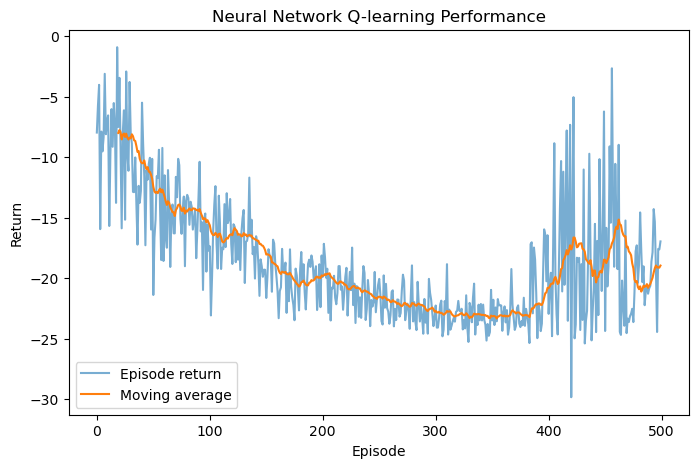

In [8]:
plt.figure(figsize=(8,5))
plt.plot(returns, alpha=0.6, label="Episode return")

window = 20
moving_avg = np.convolve(returns, np.ones(window)/window, mode='valid')
plt.plot(range(window-1, len(returns)), moving_avg, label="Moving average")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("Neural Network Q-learning Performance")
plt.legend()
plt.show()

#### Task 4

The linear model achieved higher performance, with average returns around $10$--$12$, while the neural network only reached approximately $3$ after the same amount of training.

The linear approximation performed better due to its simplicity and stability. With designed features, it was able to capture most of the relevant structure of the environment and learn efficiently from limited data.

In contrast, the neural network, although more expressive, was harder to train. The combination of Q-learning and function approximation leads to unstable targets, and without additional techniques such as replay buffers or target networks, learning is slower and less effective.

This shows that a simpler model can outperform a more complex one when training stability and data efficiency are important.


#### Task 5

Small neural network for the actor:
This outputs action probabilities.

##### Actor-Critic Model

In this part, we use two neural networks. The actor learns the policy directly by outputting probabilities for each action, while the critic learns the value of the current state. The actor decides what to do, and the critic evaluates how good the situation is.

In [ ]:
class ActorNetwork(nn.Module):
    def __init__(self, input_dim=7, hidden_dim=64, output_dim=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        logits = self.net(x)
        return torch.softmax(logits, dim=-1)


class CriticNetwork(nn.Module):
    def __init__(self, input_dim=7, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
class ActorCriticAgent:
    def __init__(self, actor_lr=1e-4, critic_lr=1e-3, gamma=0.99):
        self.gamma = gamma
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.actor = ActorNetwork().to(self.device)
        self.critic = CriticNetwork().to(self.device)

        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=actor_lr)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=critic_lr)

    def select_action(self, state_vec):
        state = torch.tensor(state_vec, dtype=torch.float32, device=self.device).unsqueeze(0)
        probs = self.actor(state)
        dist = torch.distributions.Categorical(probs)
        action = dist.sample()

        return action.item(), dist.log_prob(action)

    def update(self, state_vec, log_prob, reward, next_state_vec, done):
        state = torch.tensor(state_vec, dtype=torch.float32, device=self.device).unsqueeze(0)
        next_state = torch.tensor(next_state_vec, dtype=torch.float32, device=self.device).unsqueeze(0)

        value = self.critic(state).squeeze()
        next_value = self.critic(next_state).squeeze().detach()

        if done:
            td_target = torch.tensor(reward, dtype=torch.float32, device=self.device)
        else:
            td_target = torch.tensor(reward, dtype=torch.float32, device=self.device) + self.gamma * next_value

        advantage = td_target - value

        # Critic update
        critic_loss = advantage.pow(2)

        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()

        # Actor update
        actor_loss = -log_prob * advantage.detach()

        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()

        return actor_loss.item(), critic_loss.item()

actor critic agent

##### Actor-Critic Training

At each step, the actor samples an action from the policy and the critic estimates the state value. The temporal-difference error is used as a learning signal: the critic updates its value estimate, and the actor updates the policy so that actions with positive advantage become more likely. This allows the agent to learn a policy directly instead of learning Q-values first.

In [ ]:
env = CookieDisasterEnv(render_mode=None)
agent = ActorCriticAgent(actor_lr=1e-4, critic_lr=1e-3, gamma=0.99)

num_episodes = 500
max_steps = 200

returns = []
actor_losses = []
critic_losses = []

for ep in range(num_episodes):
    obs, info = env.reset()
    state_vec = state_to_vector(obs)

    total_reward = 0.0
    ep_actor_losses = []
    ep_critic_losses = []

    for step in range(max_steps):
        action, log_prob = agent.select_action(state_vec)
        next_obs, reward, terminated, truncated, info = env.step(action)
        next_state_vec = state_to_vector(next_obs)

        done = terminated or truncated

        actor_loss, critic_loss = agent.update(
            state_vec, log_prob, reward, next_state_vec, done
        )

        state_vec = next_state_vec
        total_reward += reward
        ep_actor_losses.append(actor_loss)
        ep_critic_losses.append(critic_loss)

        if done:
            break

    returns.append(total_reward)
    actor_losses.append(np.mean(ep_actor_losses))
    critic_losses.append(np.mean(ep_critic_losses))

    if (ep + 1) % 50 == 0:
        print(
            f"Episode {ep+1}, "
            f"avg return (last 50): {np.mean(returns[-50:]):.3f}, "
            f"avg actor loss: {np.mean(actor_losses[-50:]):.4f}, "
            f"avg critic loss: {np.mean(critic_losses[-50:]):.4f}"
        )

env.close()

c:\Users\somme\anaconda3\envs\gymenv\Lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\somme\anaconda3\envs\gymenv\Lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Episode 50, avg return (last 50): -1.101, avg critic loss: 0.0699
Episode 100, avg return (last 50): 0.796, avg critic loss: 0.0463
Episode 150, avg return (last 50): 2.288, avg critic loss: 0.0508
Episode 200, avg return (last 50): 3.971, avg critic loss: 0.0513
Episode 250, avg return (last 50): 5.702, avg critic loss: 0.0566
Episode 300, avg return (last 50): 6.806, avg critic loss: 0.0546
Episode 350, avg return (last 50): 8.387, avg critic loss: 0.0640
Episode 400, avg return (last 50): 11.565, avg critic loss: 0.0704
Episode 450, avg return (last 50): 11.985, avg critic loss: 0.0628
Episode 500, avg return (last 50): 12.497, avg critic loss: 0.0653


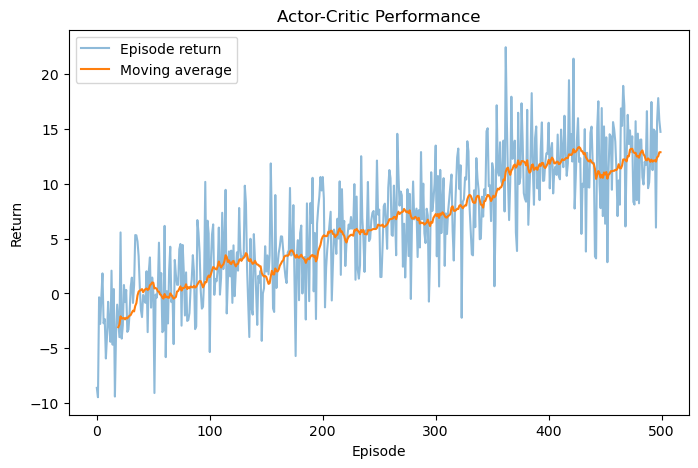

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(returns, alpha=0.6, label="Episode return")

window = 20
moving_avg = np.convolve(returns, np.ones(window)/window, mode='valid')
plt.plot(range(window-1, len(returns)), moving_avg, label="Moving average")

plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("Actor-Critic Performance")
plt.legend()
plt.show()